In [1]:
import pandas as pd

df = pd.read_csv("/content/CGWB_data_wide.csv")

In [2]:
print(df.shape)
print(df.columns.tolist())

(28076, 91)
['Unnamed: 0', 'STATE', 'DISTRICT', 'LAT', 'LON', 'SITE_TYPE', 'WLCODE', 'May 1996', 'Aug 1996', 'Nov 1996', 'Jan 1997', 'May 1997', 'Aug 1997', 'Nov 1997', 'Jan 1998', 'May 1998', 'Aug 1998', 'Nov 1998', 'Jan 1999', 'May 1999', 'Aug 1999', 'Nov 1999', 'Jan 2000', 'May 2000', 'Aug 2000', 'Nov 2000', 'Jan 2001', 'May 2001', 'Aug 2001', 'Nov 2001', 'Jan 2002', 'May 2002', 'Aug 2002', 'Nov 2002', 'Jan 2003', 'May 2003', 'Aug 2003', 'Nov 2003', 'Jan 2004', 'May 2004', 'Aug 2004', 'Nov 2004', 'Jan 2005', 'May 2005', 'Aug 2005', 'Nov 2005', 'Jan 2006', 'May 2006', 'Aug 2006', 'Nov 2006', 'Jan 2007', 'May 2007', 'Aug 2007', 'Nov 2007', 'Jan 2008', 'May 2008', 'Aug 2008', 'Nov 2008', 'Jan 2009', 'May 2009', 'Aug 2009', 'Nov 2009', 'Jan 2010', 'May 2010', 'Aug 2010', 'Nov 2010', 'Jan 2011', 'May 2011', 'Aug 2011', 'Nov 2011', 'Jan 2012', 'May 2012', 'Aug 2012', 'Nov 2012', 'Jan 2013', 'May 2013', 'Aug 2013', 'Nov 2013', 'Jan 2014', 'May 2014', 'Aug 2014', 'Nov 2014', 'Jan 2015', 'Ma

In [3]:
print(df['DISTRICT'].value_counts().head(20))

DISTRICT
Murshidabad          221
Barddhaman           220
Birbhum              204
Anantapur            201
Bankura              199
Guntur               189
Bilaspur             187
Nalgonda             184
Rangareddy           184
Palakkad             183
Raipur               179
Kurnool              178
Surguja              174
Warangal             173
East Godavari        171
Ernakulam            171
Mahbubnagar          168
South 24 Parganas    165
Thrissur             164
Malappuram           159
Name: count, dtype: int64


In [4]:
print(df[['Jan 2002', 'May 2002', 'Aug 2002', 'Nov 2002']].head())

   Jan 2002  May 2002  Aug 2002  Nov 2002
0       NaN       NaN       NaN       NaN
1       NaN       NaN       NaN       NaN
2       NaN       NaN       NaN       NaN
3       NaN       NaN       NaN       NaN
4       NaN       NaN       NaN       NaN


In [5]:
print(df[['Jan 2002', 'May 2002', 'Aug 2002', 'Nov 2002']].dtypes)

Jan 2002    float64
May 2002    float64
Aug 2002    float64
Nov 2002    float64
dtype: object


In [6]:
districts = [
    'Murshidabad',
    'Barddhaman',
    'Birbhum',
    'Anantapur',
    'Bankura'
]

months_2002 = ['Jan 2002', 'May 2002', 'Aug 2002', 'Nov 2002']

for district in districts:
    temp = df[df['DISTRICT'] == district]

    print("\n", district)
    print(temp[months_2002].notna().sum())


 Murshidabad
Jan 2002    41
May 2002    47
Aug 2002    45
Nov 2002    45
dtype: int64

 Barddhaman
Jan 2002    62
May 2002    61
Aug 2002    56
Nov 2002    59
dtype: int64

 Birbhum
Jan 2002    82
May 2002    79
Aug 2002    78
Nov 2002    77
dtype: int64

 Anantapur
Jan 2002    70
May 2002    66
Aug 2002    66
Nov 2002    65
dtype: int64

 Bankura
Jan 2002    83
May 2002    74
Aug 2002    77
Nov 2002    77
dtype: int64


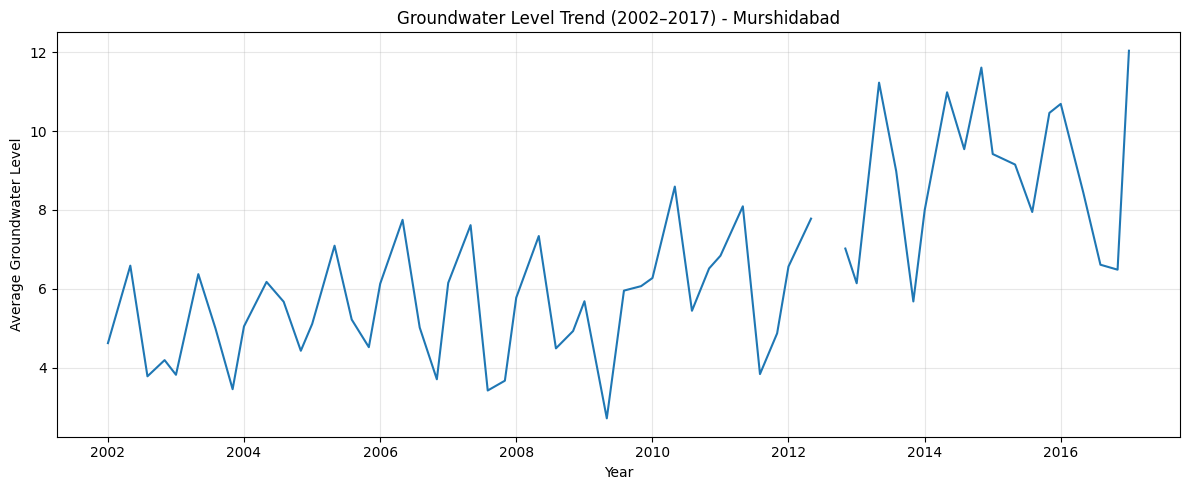

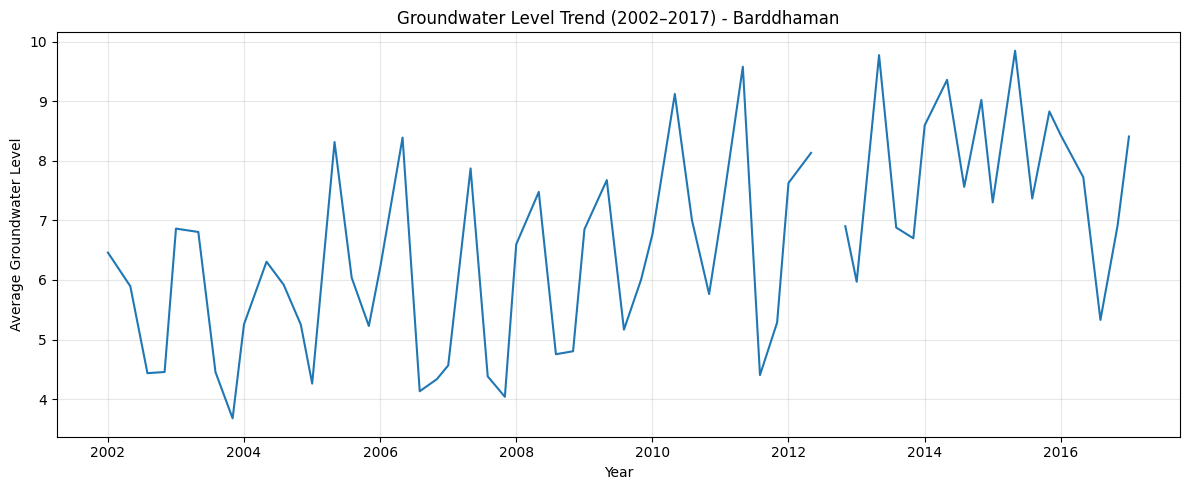

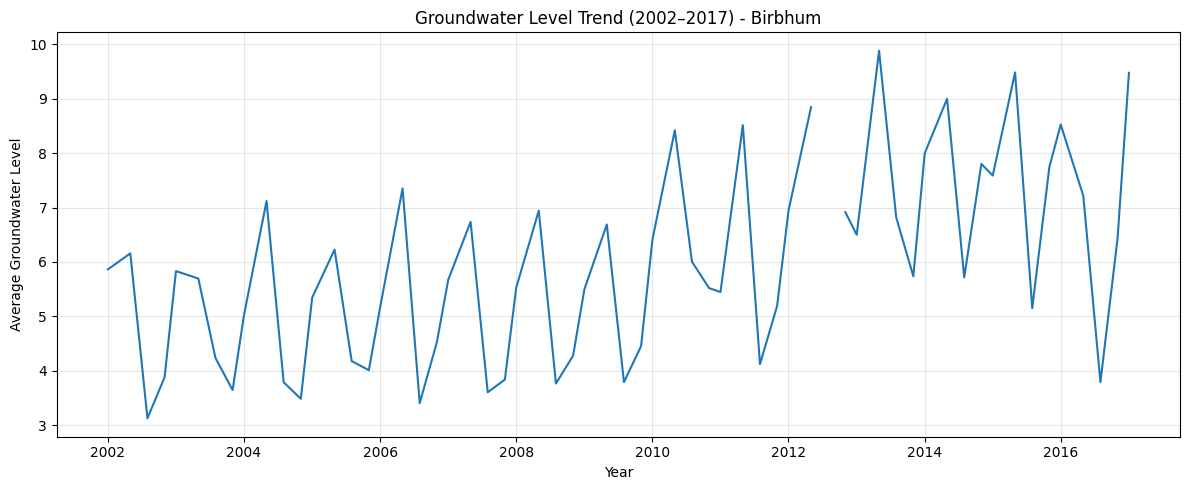

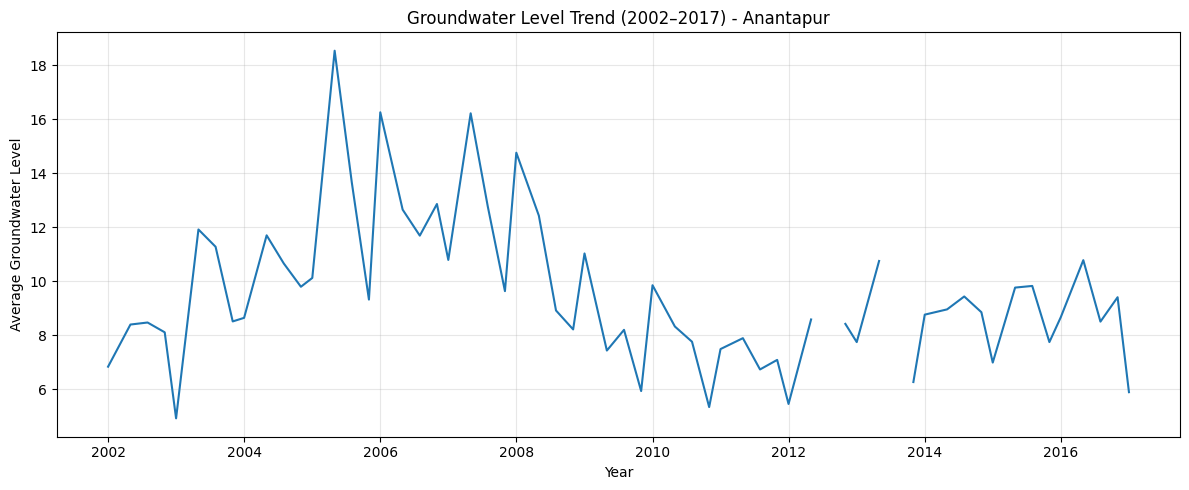

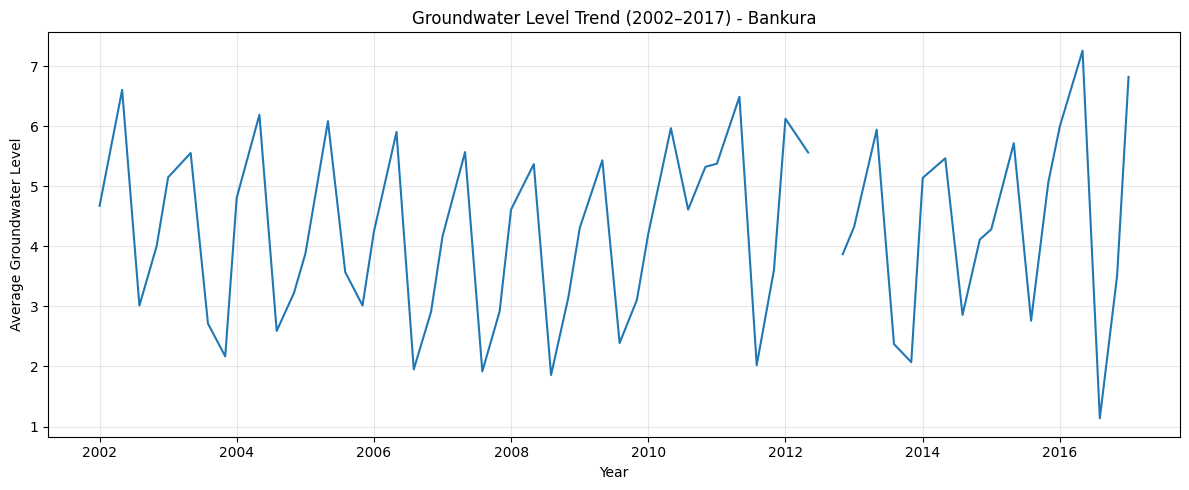

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 5 selected districts
districts = [
    'Murshidabad',
    'Barddhaman',
    'Birbhum',
    'Anantapur',
    'Bankura'
]

# Select all date columns
date_columns = [
    col for col in df.columns
    if any(month in col for month in ['Jan ', 'May ', 'Aug ', 'Nov '])
]

# Keep only district + date columns
data = df[['DISTRICT'] + date_columns].copy()

# Convert wide format → long format
long_df = data.melt(
    id_vars='DISTRICT',
    var_name='Date',
    value_name='GWL'
)

# Convert Date column
long_df['Date'] = pd.to_datetime(
    long_df['Date'],
    format='%b %Y'
)

# Make GWL numeric
long_df['GWL'] = pd.to_numeric(
    long_df['GWL'],
    errors='coerce'
)

# Keep only 2002 onwards
long_df = long_df[
    (long_df['Date'] >= '2002-01-01')
]

# Create folder for charts
os.makedirs('GWL_Charts_2002_2017', exist_ok=True)

# Create 5 charts
for district in districts:

    temp = long_df[
        long_df['DISTRICT'] == district
    ].copy()

    # District-wise average GWL
    temp = (
        temp.groupby('Date')['GWL']
        .mean()
        .reset_index()
        .sort_values('Date')
    )

    plt.figure(figsize=(12, 5))

    plt.plot(
        temp['Date'],
        temp['GWL'],
        linewidth=1.5
    )

    plt.title(
        f'Groundwater Level Trend (2002–2017) - {district}'
    )

    plt.xlabel('Year')
    plt.ylabel('Average Groundwater Level')

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    # Save PNG
    filename = f'GWL_Charts_2002_2017/{district}_GWL_Trend.png'

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()
    plt.close()

In [8]:
import shutil

shutil.make_archive(
    "AquaIQ_GWL_Charts_2002_2017",
    "zip",
    "GWL_Charts_2002_2017"
)

print("ZIP created successfully!")

ZIP created successfully!


In [9]:
from google.colab import files

files.download("AquaIQ_GWL_Charts_2002_2017.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
import json

with open("/content/india_districts.geojson", "r") as f:
    geojson = json.load(f)

print("Number of features:", len(geojson["features"]))

Number of features: 760


In [11]:
print(geojson["features"][0]["properties"])

{'district': 'Aizawl', 'dt_code': '261', 'st_nm': 'Mizoram', 'st_code': '15', 'year': '2011_c'}


In [12]:
df['DISTRICT']

,DISTRICT
0,Adilabad
1,Adilabad
2,Adilabad
3,Adilabad
4,Adilabad
...,...
28071,Y.s.r.
28072,Y.s.r.
28073,Y.s.r.
28074,Y.s.r.


In [13]:
import json

with open("/content/india_districts.geojson", "r") as f:
    geojson = json.load(f)

print("Number of features:", len(geojson["features"]))

Number of features: 760


In [14]:
print(geojson["features"][0]["properties"])

{'district': 'Aizawl', 'dt_code': '261', 'st_nm': 'Mizoram', 'st_code': '15', 'year': '2011_c'}


In [15]:
geojson_districts = set(
    feature["properties"]["district"]
    for feature in geojson["features"]
)

print("GeoJSON districts:", len(geojson_districts))

KeyError: 'district'

In [16]:
for i, feature in enumerate(geojson["features"][:10]):
    print(i, feature["properties"])

0 {'district': 'Aizawl', 'dt_code': '261', 'st_nm': 'Mizoram', 'st_code': '15', 'year': '2011_c'}
1 {'district': 'Champhai', 'dt_code': '262', 'st_nm': 'Mizoram', 'st_code': '15', 'year': '2011_c'}
2 {'district': 'Kolasib', 'dt_code': '263', 'st_nm': 'Mizoram', 'st_code': '15', 'year': '2011_c'}
3 {'district': 'Lawngtlai', 'dt_code': '264', 'st_nm': 'Mizoram', 'st_code': '15', 'year': '2011_c'}
4 {'district': 'Lunglei', 'dt_code': '265', 'st_nm': 'Mizoram', 'st_code': '15', 'year': '2011_c'}
5 {'district': 'Mamit', 'dt_code': '266', 'st_nm': 'Mizoram', 'st_code': '15', 'year': '2011_c'}
6 {'district': 'Saiha', 'dt_code': '267', 'st_nm': 'Mizoram', 'st_code': '15', 'year': '2011_c'}
7 {'district': 'Serchhip', 'dt_code': '268', 'st_nm': 'Mizoram', 'st_code': '15', 'year': '2011_c'}
8 {'district': 'Khawzawl', 'dt_code': '996', 'st_nm': 'Mizoram', 'st_code': '15', 'year': '2019'}
9 {'district': 'Hnahthial', 'dt_code': '994', 'st_nm': 'Mizoram', 'st_code': '15', 'year': '2019'}


In [17]:
df["DISTRICT"]

,DISTRICT
0,Adilabad
1,Adilabad
2,Adilabad
3,Adilabad
4,Adilabad
...,...
28071,Y.s.r.
28072,Y.s.r.
28073,Y.s.r.
28074,Y.s.r.


In [18]:
# Get unique district names from GeoJSON
geojson_districts = set(
    feature["properties"]["district"]
    for feature in geojson["features"]
    if "district" in feature["properties"]
)

# Get unique district names from CGWB
cgwb_districts = set(
    df["DISTRICT"].dropna().unique()
)

print("GeoJSON unique districts:", len(geojson_districts))
print("CGWB unique districts:", len(cgwb_districts))

GeoJSON unique districts: 719
CGWB unique districts: 522


In [19]:
# Exact matches
matched = geojson_districts.intersection(cgwb_districts)

print("Exact matched districts:", len(matched))

Exact matched districts: 439


In [20]:
# Names present in GeoJSON but not CGWB
geojson_only = geojson_districts - cgwb_districts

print("GeoJSON districts NOT found in CGWB:")
print(sorted(geojson_only))

GeoJSON districts NOT found in CGWB:
['Agar Malwa', 'Ahmedabad', 'Ahmednagar', 'Aizawl', 'Alipurduar', 'Almora', 'Amethi', 'Amroha', 'Angul', 'Anjaw', 'Aravalli', 'Ayodhya', 'Bagalkote', 'Bageshwar', 'Baksa', 'Balasore', 'Ballari', 'Balod', 'Baloda Bazar', 'Bametara', 'Banaskantha', 'Bandipora', 'Barabanki', 'Baramulla', 'Barpeta', 'Beed', 'Belagavi', 'Bengaluru Rural', 'Bengaluru Urban', 'Bhadohi', 'Bhadradri Kothagudem', 'Biswanath', 'Bongaigaon', 'Botad', 'Boudh', 'Budgam', 'Buldhana', 'Cachar', 'Chamarajanagara', 'Chamba', 'Chamoli', 'Champawat', 'Champhai', 'Chandel', 'Chandigarh', 'Charaideo', 'Charkhi Dadri', 'Chengalpattu', 'Chhota Udaipur', 'Chikkamagaluru', 'Chirang', 'Chittorgarh', 'Churachandpur', 'Cooch Behar', 'Dadra and Nagar Haveli', 'Dahod', 'Daman', 'Dang', 'Darjeeling', 'Darrang', 'Dehradun', 'Delhi', 'Deogarh', 'Devbhumi Dwarka', 'Dhemaji', 'Dholpur', 'Dhubri', 'Dibrugarh', 'Dima Hasao', 'Diu', 'Doda', 'East Champaran', 'East Jaintia Hills', 'East Kameng', 'East Sik

In [21]:
# Names present in CGWB but not GeoJSON
cgwb_only = cgwb_districts - geojson_districts

print("\nCGWB districts NOT found in GeoJSON:")
print(sorted(cgwb_only))


CGWB districts NOT found in GeoJSON:
['Ahmadabad', 'Ahmadnagar', 'Allahabad', 'Anugul', 'Badgam', 'Bagalkot', 'Baleshwar', 'Banas Kantha', 'Bandipore', 'Bangalore', 'Bangalore Rural', 'Bara Banki', 'Baramula', 'Barddhaman', 'Bauda', 'Belgaum', 'Bellary', 'Bid', 'Buldana', 'Chamrajnagar', 'Chikmagalur', 'Chittaurgarh', 'Darjiling', 'Debagarh', 'Dhaulpur', 'Dohad', 'East Nimar', 'Faizabad', 'Firozpur', 'Garhchiroli', 'Gondiya', 'Gulbarga', 'Gurgaon', 'Haora', 'Hugli', 'Jagatsinghapur', 'Jaintia Hills', 'Jajapur', 'Jalor', 'Janjgir-champa', 'Jhunjhunun', 'Jyotiba Phule Nagar', 'Kachchh', 'Kaimur (bhabua)', 'Kanniyakumari', 'Kheri', 'Koch Bihar', 'Kodarma', 'Leh (ladakh)', 'Mahamaya Nagar', 'Mahbubnagar', 'Mahesana', 'Maldah', 'Mewat', 'Muktsar', 'Mumbai Suburban', 'Mysore', 'Nagappattinam', 'Narsimhapur', 'Panch Mahals', 'Pashchim Champaran', 'Pashchim Medinipur', 'Pashchimi Singhbhum', 'Purba Champaran', 'Purbi Singhbhum', 'Puruliya', 'Rangareddy', 'Ri Bhoi', 'Sabar Kantha', 'Sahibzada 

In [22]:
import re

def normalize_name(name):
    name = str(name).lower().strip()
    name = re.sub(r'[^a-z0-9]', '', name)
    return name

geojson_normalized = {
    normalize_name(name): name
    for name in geojson_districts
}

cgwb_normalized = {
    normalize_name(name): name
    for name in cgwb_districts
}

normalized_matches = set(geojson_normalized.keys()) & set(cgwb_normalized.keys())

print("Matches after normalization:", len(normalized_matches))

Matches after normalization: 447


In [23]:
geojson_unmatched = set(geojson_normalized.keys()) - normalized_matches
cgwb_unmatched = set(cgwb_normalized.keys()) - normalized_matches

print("Remaining GeoJSON unmatched:", len(geojson_unmatched))
print("Remaining CGWB unmatched:", len(cgwb_unmatched))

Remaining GeoJSON unmatched: 272
Remaining CGWB unmatched: 75


In [24]:
print("\nGeoJSON unmatched names:")
for name in sorted(geojson_unmatched):
    print(geojson_normalized[name])


GeoJSON unmatched names:
Agar Malwa
Ahmedabad
Ahmednagar
Aizawl
Alipurduar
Almora
Amethi
Amroha
Angul
Anjaw
Aravalli
Ayodhya
Bagalkote
Bageshwar
Baksa
Balasore
Ballari
Balod
Baloda Bazar
Bametara
Bandipora
Baramulla
Barpeta
Beed
Belagavi
Bengaluru Rural
Bengaluru Urban
Bhadohi
Bhadradri Kothagudem
Biswanath
Bongaigaon
Botad
Boudh
Budgam
Buldhana
Cachar
Chamarajanagara
Chamba
Chamoli
Champawat
Champhai
Chandel
Chandigarh
Charaideo
Charkhi Dadri
Chengalpattu
Chhota Udaipur
Chikkamagaluru
Chirang
Chittorgarh
Churachandpur
Cooch Behar
Dadra and Nagar Haveli
Dahod
Daman
Dang
Darjeeling
Darrang
Dehradun
Delhi
Deogarh
Devbhumi Dwarka
Dhemaji
Dholpur
Dhubri
Dibrugarh
Dima Hasao
Diu
Doda
East Champaran
East Jaintia Hills
East Kameng
East Sikkim
East Singhbhum
Fazilka
Ferozepur
Firozabad
Gadchiroli
Ganderbal
Gariaband
Ghazipur
Gir Somnath
Goalpara
Golaghat
Gomati
Gondia
Gurugram
Hailakandi
Hapur
Haridwar
Hathras
Hnahthial
Hojai
Hooghly
Howrah
Imphal West
Jagatsinghpur
Jagtial
Jajpur
Jalore
Jang

In [25]:
print("\nCGWB unmatched names:")
for name in sorted(cgwb_unmatched):
    print(cgwb_normalized[name])


CGWB unmatched names:
Ahmadabad
Ahmadnagar
Allahabad
Anugul
Badgam
Bagalkot
Baleshwar
Bandipore
Bangalore
Bangalore Rural
Baramula
Barddhaman
Bauda
Belgaum
Bellary
Bid
Buldana
Chamrajnagar
Chikmagalur
Chittaurgarh
Darjiling
Debagarh
Dhaulpur
Dohad
East Nimar
Faizabad
Firozpur
Garhchiroli
Gondiya
Gulbarga
Gurgaon
Haora
Hugli
Jagatsinghapur
Jaintia Hills
Jajapur
Jalor
Jhunjhunun
Jyotiba Phule Nagar
Kachchh
Kaimur (bhabua)
Kanniyakumari
Kheri
Koch Bihar
Kodarma
Leh (ladakh)
Mahamaya Nagar
Mahbubnagar
Mahesana
Maldah
Mewat
Muktsar
Mumbai Suburban
Mysore
Nagappattinam
Narsimhapur
Panch Mahals
Pashchim Champaran
Pashchimi Singhbhum
Pashchim Medinipur
Purba Champaran
Purbi Singhbhum
Puruliya
Sahibzada Ajit Singh Nagar
Sant Ravi Das Nagar(bhadohi)
Saran (chhapra)
Shimoga
Sri Potti Sriramulu Nellore
The Dangs
The Nilgiris
Tumkur
Virudunagar
Warangal
West Nimar
Y.s.r.


In [26]:
!pip install rapidfuzz -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 31.5 MB/s eta 0:00:00


In [27]:
from rapidfuzz import process, fuzz

# Convert normalized GeoJSON names back to original names
geojson_names = list(geojson_districts)

for cgwb_name in sorted(cgwb_districts):

    # Skip names that already have an exact normalized match
    if normalize_name(cgwb_name) in normalized_matches:
        continue

    result = process.extractOne(
        cgwb_name,
        geojson_names,
        scorer=fuzz.token_sort_ratio
    )

    if result:
        match, score, _ = result
        print(f"{cgwb_name:40} -> {match:40} Score: {score}")

Ahmadabad                                -> Ahmedabad                                Score: 88.88888888888889
Ahmadnagar                               -> Ahmednagar                               Score: 90.0
Allahabad                                -> Adilabad                                 Score: 70.58823529411764
Anugul                                   -> Angul                                    Score: 90.9090909090909
Badgam                                   -> Budgam                                   Score: 83.33333333333334
Bagalkot                                 -> Bagalkote                                Score: 94.11764705882352
Baleshwar                                -> Bageshwar                                Score: 88.88888888888889
Bandipore                                -> Bandipora                                Score: 88.88888888888889
Bangalore                                -> Bagalkote                                Score: 77.77777777777779
Bangalore Rural         

In [28]:
district_mapping = {
    "Ahmadabad": "Ahmedabad",
    "Ahmadnagar": "Ahmednagar",
    "Anugul": "Angul",
    "Badgam": "Budgam",
    "Bagalkot": "Bagalkote",
    "Baleshwar": "Balasore",
    "Bandipore": "Bandipora",
    "Bangalore Rural": "Bengaluru Rural",
    "Baramula": "Baramulla",
    "Belgaum": "Belagavi",
    "Bellary": "Ballari",
    "Buldana": "Buldhana",
    "Chamrajnagar": "Chamarajanagara",
    "Chikmagalur": "Chikkamagaluru",
    "Chittaurgarh": "Chittorgarh",
    "Darjiling": "Darjeeling",
    "Debagarh": "Deogarh",
    "Dhaulpur": "Dholpur",
    "Firozpur": "Ferozepur",
    "Garhchiroli": "Gadchiroli",
    "Gondiya": "Gondia",
    "Jagatsinghapur": "Jagatsinghpur",
    "Jajapur": "Jajpur",
    "Jalor": "Jalore",
    "Jhunjhunun": "Jhunjhunu",
    "Kanniyakumari": "Kanyakumari",
    "Koch Bihar": "Cooch Behar",
    "Kodarma": "Koderma",
    "Mahbubnagar": "Mahabubnagar",
    "Mahesana": "Mehsana",
    "Maldah": "Malda",
    "Nagappattinam": "Nagapattinam",
    "Narsimhapur": "Narsinghpur",
    "Pashchim Medinipur": "Paschim Medinipur",
    "Puruliya": "Purulia",
    "Shimoga": "Shivamogga",
    "The Nilgiris": "Nilgiris",
    "Tumkur": "Tumakuru",
    "Virudunagar": "Virudhunagar",
}

In [29]:
print("Mappings created:", len(district_mapping))

Mappings created: 39


In [30]:
df['DISTRICT_MAPPED'] = df['DISTRICT'].replace(district_mapping)

print(df[['DISTRICT', 'DISTRICT_MAPPED']].drop_duplicates().head(30))

                        DISTRICT             DISTRICT_MAPPED
0                       Adilabad                    Adilabad
142                         Agra                        Agra
177                    Ahmadabad                   Ahmedabad
269                   Ahmadnagar                  Ahmednagar
367   Sahibzada Ajit Singh Nagar  Sahibzada Ajit Singh Nagar
402                        Ajmer                       Ajmer
446                        Akola                       Akola
496                      Aligarh                     Aligarh
524                    Alirajpur                   Alirajpur
539                    Allahabad                   Allahabad
580                    Alappuzha                   Alappuzha
718                        Alwar                       Alwar
795                       Ambala                      Ambala
865               Ambedkar Nagar              Ambedkar Nagar
885                     Amravati                    Amravati
1027                    

In [31]:
cgwb_mapped = set(df['DISTRICT_MAPPED'].dropna().unique())

final_matches = geojson_districts.intersection(cgwb_mapped)

print("Final matched districts:", len(final_matches))

Final matched districts: 478


In [32]:
final_unmatched = cgwb_mapped - geojson_districts

print("CGWB districts still unmatched:", len(final_unmatched))
print(sorted(final_unmatched))

CGWB districts still unmatched: 44
['Allahabad', 'Banas Kantha', 'Bangalore', 'Bara Banki', 'Barddhaman', 'Bauda', 'Bid', 'Dohad', 'East Nimar', 'Faizabad', 'Gulbarga', 'Gurgaon', 'Haora', 'Hugli', 'Jaintia Hills', 'Janjgir-champa', 'Jyotiba Phule Nagar', 'Kachchh', 'Kaimur (bhabua)', 'Kheri', 'Leh (ladakh)', 'Mahamaya Nagar', 'Mewat', 'Muktsar', 'Mumbai Suburban', 'Mysore', 'Panch Mahals', 'Pashchim Champaran', 'Pashchimi Singhbhum', 'Purba Champaran', 'Purbi Singhbhum', 'Rangareddy', 'Ri Bhoi', 'Sabar Kantha', 'Sahibzada Ajit Singh Nagar', 'Sant Ravi Das Nagar(bhadohi)', 'Saraikela-kharsawan', 'Saran (chhapra)', 'Siddharth Nagar', 'Sri Potti Sriramulu Nellore', 'The Dangs', 'Warangal', 'West Nimar', 'Y.s.r.']


In [33]:
import pandas as pd

# Create validation rows
validation = []

# 1. Exact GeoJSON ↔ CGWB matches
for name in sorted(matched):
    validation.append({
        "CGWB_Name": name,
        "GeoJSON_Name": name,
        "Status": "Exact Match"
    })

# 2. Our 39 safe mappings
for cgwb_name, geojson_name in district_mapping.items():
    validation.append({
        "CGWB_Name": cgwb_name,
        "GeoJSON_Name": geojson_name,
        "Status": "Mapped Match"
    })

# 3. Remaining unmatched CGWB names
for name in sorted(final_unmatched):
    validation.append({
        "CGWB_Name": name,
        "GeoJSON_Name": "",
        "Status": "Unmatched"
    })

validation_df = pd.DataFrame(validation)

print(validation_df["Status"].value_counts())

Status
Exact Match     439
Unmatched        44
Mapped Match     39
Name: count, dtype: int64


In [34]:
validation_df.to_csv(
    "district_name_validation.csv",
    index=False
)

print("Validation report created!")

Validation report created!


In [35]:
validation_df.head(20)

,CGWB_Name,GeoJSON_Name,Status
0,Adilabad,Adilabad,Exact Match
1,Agra,Agra,Exact Match
2,Ajmer,Ajmer,Exact Match
3,Akola,Akola,Exact Match
4,Alappuzha,Alappuzha,Exact Match
5,Aligarh,Aligarh,Exact Match
6,Alirajpur,Alirajpur,Exact Match
7,Alwar,Alwar,Exact Match
8,Ambala,Ambala,Exact Match
9,Ambedkar Nagar,Ambedkar Nagar,Exact Match


In [36]:
print(validation_df["Status"].value_counts())

Status
Exact Match     439
Unmatched        44
Mapped Match     39
Name: count, dtype: int64


In [37]:
print(validation_df.tail(50))

                        CGWB_Name       GeoJSON_Name        Status
472            Pashchim Medinipur  Paschim Medinipur  Mapped Match
473                      Puruliya            Purulia  Mapped Match
474                       Shimoga         Shivamogga  Mapped Match
475                  The Nilgiris           Nilgiris  Mapped Match
476                        Tumkur           Tumakuru  Mapped Match
477                   Virudunagar       Virudhunagar  Mapped Match
478                     Allahabad                        Unmatched
479                  Banas Kantha                        Unmatched
480                     Bangalore                        Unmatched
481                    Bara Banki                        Unmatched
482                    Barddhaman                        Unmatched
483                         Bauda                        Unmatched
484                           Bid                        Unmatched
485                         Dohad                        Unmat

In [38]:
validation_df.to_csv(
    "district_name_validation.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [39]:
from google.colab import files

files.download("district_name_validation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>